In [9]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import utils

In [10]:
data_dir = '/Users/rebekahzhang/data/behavior_data'
exp = 'exp2'
data_folder = os.path.join(data_dir, exp)
figure_folder = os.path.join(data_dir, 'timing_anchor_cv')
os.makedirs(figure_folder, exist_ok=True)

In [11]:
trials_training = pd.read_csv(os.path.join(data_folder, 'trials_training_filtered2.csv'))
print(trials_training.shape)
trials_training.head(3)

(605819, 80)


,session_trial_num,block_trial_num,block_num,start_time,end_time,bg_drawn,bg_length,bg_repeats,num_bg_licks,bg_repeat_rate,...,reward_rate_past_5min_in_block,reward_rate_past_10min_in_block,cumulative_reward,group,dir,mouse,date,time,avg_tw,session
0,0.0,0.0,0.0,1.706626e+09,1.706626e+09,1.2,1.217297,2,1,0.821492,...,0.0,0.0,0.0,s,2024-01-30_09-52-34_RZ034,RZ034,2024-01-30,09-52-34,0.47,0
1,1.0,1.0,0.0,1.706626e+09,1.706626e+09,1.2,7.525090,13,13,1.727554,...,0.0,0.0,0.0,s,2024-01-30_09-52-34_RZ034,RZ034,2024-01-30,09-52-34,0.47,0
2,2.0,2.0,0.0,1.706626e+09,1.706626e+09,1.2,1.299892,2,1,0.769295,...,0.0,0.0,0.0,s,2024-01-30_09-52-34_RZ034,RZ034,2024-01-30,09-52-34,0.47,0


## Timing references

Each column measures how long the mouse waited, measured from a different candidate anchor point.
We want the anchor that produces the **lowest CV** (= std / mean) across trials within a session —
that's the reference the animal's internal clock is most tightly locked to.

In [12]:
timing_refs = {
    'cue_on':        'time_waited_since_cue_on',
    'cue_off':       'time_waited',
    'last_reward':   'time_waited_since_last_reward',
    'last_lick':     'time_waited_since_last_lick',
    'last_lick_bout':'time_waited_since_last_lick_bout',
}

# Sanity check: which columns are actually present?
for label, col in timing_refs.items():
    present = col in trials_training.columns
    n_valid = trials_training[col].notna().sum() if present else 0
    print(f"  {label:16s} → {col:40s}  present={present}  n_valid={n_valid}")

  cue_on           → time_waited_since_cue_on                  present=True  n_valid=605819
  cue_off          → time_waited                               present=True  n_valid=605819
  last_reward      → time_waited_since_last_reward             present=True  n_valid=600486
  last_lick        → time_waited_since_last_lick               present=True  n_valid=605588
  last_lick_bout   → time_waited_since_last_lick_bout          present=True  n_valid=604356


## Filter trials

Only hit trials contribute a real wait time; miss trials are right-censored at 60 s.
Toggle `good_trial_only` to additionally exclude trials contaminated by background licks.

In [13]:
good_trial_only = False   # set True to exclude bg-lick trials
BG_REPEAT_CUTOFF = {'s': 8, 'l': 16}

trials = trials_training[~trials_training['miss_trial']].copy()
if good_trial_only:
    trials = trials[trials['good_trial']]

# Drop trials where mouse restarted the background too many times (not engaged)
n_before = len(trials)
trials = trials[trials.apply(lambda r: r['bg_repeats'] <= BG_REPEAT_CUTOFF.get(r['group'], np.inf), axis=1)]
n_dropped = n_before - len(trials)
print(f"Dropped {n_dropped:,} trials ({n_dropped / n_before:.1%}) with bg_repeats above cutoff")
print(f"{len(trials):,} hit trials remaining  ({trials['dir'].nunique()} sessions)")

Dropped 22,587 trials (3.8%) with bg_repeats above cutoff
577,249 hit trials remaining  (1638 sessions)


## Compute CV per session × reference

In [14]:
def cv(x):
    """Coefficient of variation; NaN if fewer than 3 valid observations."""
    x = x.dropna()
    if len(x) < 3 or x.mean() == 0:
        return np.nan
    return x.std() / x.mean()

cv_rows = []
for label, col in timing_refs.items():
    if col not in trials.columns:
        continue
    per_session = (
        trials.groupby(['dir', 'mouse', 'group'])[col]
        .apply(cv)
        .reset_index()
        .rename(columns={col: 'cv'})
    )
    per_session['reference'] = label
    cv_rows.append(per_session)

session_cvs = pd.concat(cv_rows, ignore_index=True)
print(session_cvs.groupby('reference')['cv'].describe().round(3))

                 count   mean    std    min    25%    50%    75%     max
reference                                                               
cue_off         1638.0  1.238  0.427  0.374  0.889  1.155  1.517   3.672
cue_on          1638.0  0.606  0.247  0.276  0.462  0.547  0.687   5.027
last_lick       1638.0  1.250  2.042  0.182  0.435  0.679  1.372  21.100
last_lick_bout  1638.0  2.098  3.028  0.212  0.663  1.195  1.859  20.966
last_reward     1638.0  1.720  2.113  0.458  0.735  0.825  1.078  12.326


## Plots

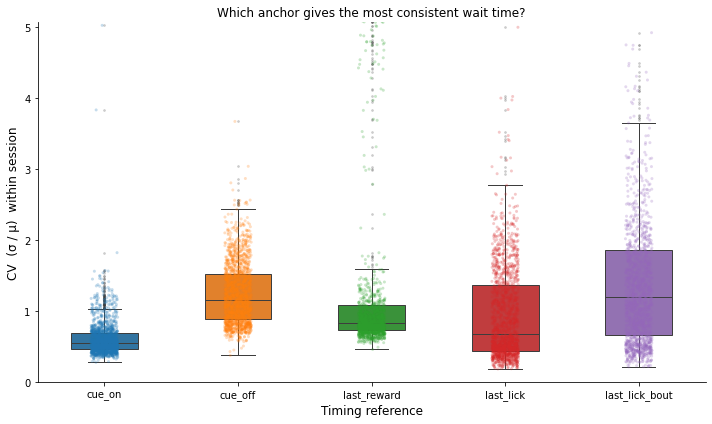

In [15]:
ref_order = list(timing_refs.keys())

# Clip y-axis at 95th percentile so outliers don't squish the boxes
y_cap = session_cvs['cv'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=session_cvs, x='reference', y='cv',
    order=ref_order, hue='reference', legend=False,
    palette='tab10', width=0.5,
    flierprops=dict(marker='.', markersize=3, alpha=0.3),
    ax=ax
)
# Overlay individual session points
sns.stripplot(
    data=session_cvs, x='reference', y='cv',
    order=ref_order, hue='reference', legend=False,
    palette='tab10', size=3, alpha=0.25, jitter=True,
    ax=ax
)
ax.set_ylim(0, y_cap)
ax.set_xlabel('Timing reference', fontsize=12)
ax.set_ylabel('CV  (σ / μ)  within session', fontsize=12)
ax.set_title('Which anchor gives the most consistent wait time?')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'cv_by_reference_boxplot.png'), dpi=150)
plt.show()

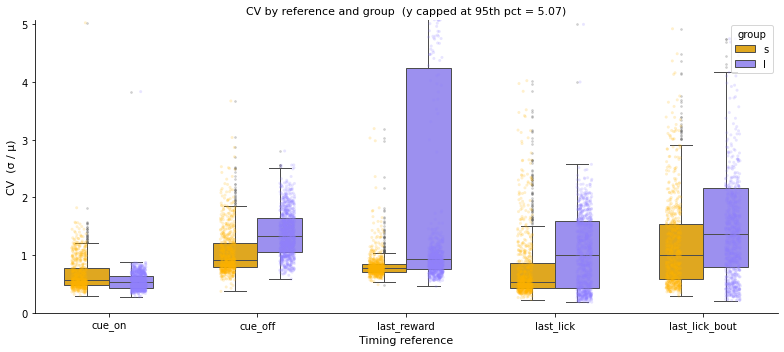

In [16]:
if 'group' in session_cvs.columns and session_cvs['group'].nunique() > 1:
    y_cap = session_cvs['cv'].quantile(0.95)

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(
        data=session_cvs, x='reference', y='cv', hue='group',
        order=ref_order, hue_order=['s', 'l'],
        palette={'s': '#ffb400', 'l': '#9080ff'},
        width=0.6, flierprops=dict(marker='.', markersize=3, alpha=0.3),
        ax=ax
    )
    sns.stripplot(
        data=session_cvs, x='reference', y='cv', hue='group',
        order=ref_order, hue_order=['s', 'l'],
        palette={'s': '#ffb400', 'l': '#9080ff'},
        size=3, alpha=0.2, jitter=True, dodge=True, legend=False,
        ax=ax
    )
    ax.set_ylim(0, y_cap)
    ax.set_xlabel('Timing reference', fontsize=11)
    ax.set_ylabel('CV  (σ / μ)', fontsize=11)
    ax.set_title(f'CV by reference and group  (y capped at 95th pct = {y_cap:.2f})', fontsize=11)
    ax.legend(title='group', loc='upper right')
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(figure_folder, 'cv_by_reference_group.png'), dpi=150)
    plt.show()

## Which reference wins each session?

For each session, find the reference whose CV is lowest (the empirical anchor).

Sessions where each reference wins (lowest CV):
cue_on            867
last_lick         575
last_reward       137
last_lick_bout     57
cue_off             2


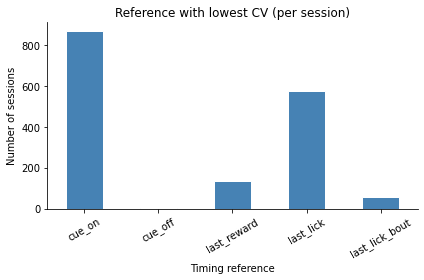

In [17]:
cv_pivot = session_cvs.pivot_table(index='dir', columns='reference', values='cv')
cv_pivot = cv_pivot[ref_order]   # enforce column order

cv_pivot['best_ref'] = cv_pivot.idxmin(axis=1)
winner_counts = cv_pivot['best_ref'].value_counts()
print("Sessions where each reference wins (lowest CV):")
print(winner_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
winner_counts.reindex(ref_order).plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Timing reference')
ax.set_ylabel('Number of sessions')
ax.set_title('Reference with lowest CV (per session)')
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'winner_per_session.png'), dpi=150)
plt.show()

## Session-level heatmap

Each row is a session; colour = CV.  Sessions sorted by cue_off CV so patterns are easier to spot.

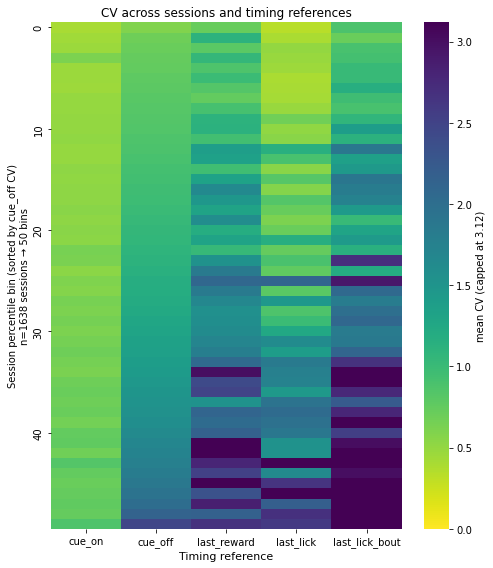

In [18]:
N_BINS = 50   # number of session percentile bins

heat_data = cv_pivot[ref_order].sort_values('cue_off').reset_index(drop=True)

# Bin sorted sessions into N_BINS equal groups, take the mean CV per bin
heat_data['bin'] = pd.cut(heat_data.index, bins=N_BINS, labels=False)
heat_binned = heat_data.groupby('bin')[ref_order].mean()

# Cap colour scale at 95th percentile so a few large-CV sessions don't wash out the palette
vmax = heat_binned.stack().quantile(0.95)

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(
    heat_binned, cmap='viridis_r', ax=ax,
    vmin=0, vmax=vmax,
    cbar_kws={'label': f'mean CV (capped at {vmax:.2f})'},
    yticklabels=10   # label every 10th bin (= every 20th percentile)
)
ax.set_xlabel('Timing reference', fontsize=11)
ax.set_ylabel(f'Session percentile bin (sorted by cue_off CV)\nn={len(heat_data)} sessions → {N_BINS} bins', fontsize=10)
ax.set_title('CV across sessions and timing references', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'cv_heatmap.png'), dpi=150)
plt.show()

## CV vs. bg_drawn

Does the "winning" reference depend on how long the background period was?

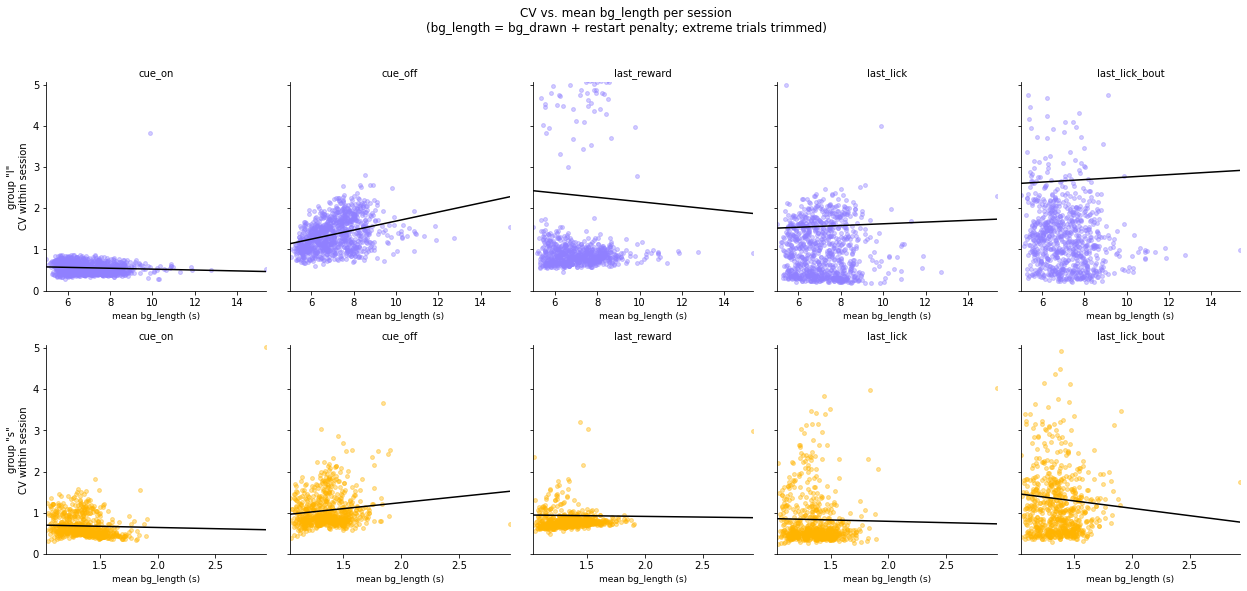

In [19]:
# bg_length = actual experienced delay (bg_drawn + restart penalty from bg licks)
bg_per_session = (
    trials.groupby(['dir', 'group'])['bg_length']
    .mean()
    .reset_index()
    .rename(columns={'bg_length': 'mean_bg_length'})
)
cv_with_bg = session_cvs.merge(bg_per_session, on=['dir', 'group'], how='left')

groups = sorted(cv_with_bg['group'].dropna().unique())
group_palette = {'s': '#ffb400', 'l': '#9080ff'}
y_cap = cv_with_bg['cv'].quantile(0.95)
n_refs = len(timing_refs)

fig, axes = plt.subplots(
    len(groups), n_refs,
    figsize=(3.5 * n_refs, 4 * len(groups)),
    sharey=True   # shared y across all panels; x is per-row since ranges differ by group
)

for row, grp in enumerate(groups):
    grp_data = cv_with_bg[cv_with_bg['group'] == grp]
    color = group_palette.get(grp, 'gray')

    # share x within each row
    x_min = grp_data['mean_bg_length'].min()
    x_max = grp_data['mean_bg_length'].max()

    for col, (label, _) in enumerate(timing_refs.items()):
        ax = axes[row, col]
        sub = grp_data[grp_data['reference'] == label].dropna(subset=['cv', 'mean_bg_length'])
        ax.scatter(sub['mean_bg_length'], sub['cv'], alpha=0.4, s=15, color=color)
        if len(sub) > 5:
            m, b = np.polyfit(sub['mean_bg_length'], sub['cv'], 1)
            xr = np.linspace(x_min, x_max, 50)
            ax.plot(xr, m * xr + b, color='black', lw=1.5)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, y_cap)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('mean bg_length (s)', fontsize=9)
        if col == 0:
            ax.set_ylabel(f'group "{grp}"\nCV within session', fontsize=10)
        sns.despine(ax=ax)

fig.suptitle('CV vs. mean bg_length per session\n'
             '(bg_length = bg_drawn + restart penalty; extreme trials trimmed)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'cv_vs_bg_length.png'), dpi=150, bbox_inches='tight')
plt.show()

## Paired comparison

Compare the two most interesting references head-to-head (one dot per session).
Points below the diagonal → reference on y-axis wins (lower CV).

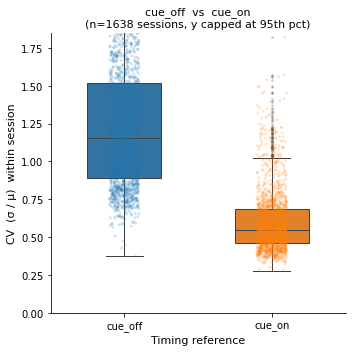

In [20]:
ref_a = 'cue_off'
ref_b = 'cue_on'

pair = cv_pivot[[ref_a, ref_b]].dropna().reset_index()
pair_long = pair.melt(id_vars='dir', value_vars=[ref_a, ref_b],
                      var_name='reference', value_name='cv')

y_cap = pair_long['cv'].quantile(0.95)

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(
    data=pair_long, x='reference', y='cv',
    order=[ref_a, ref_b], hue='reference', legend=False,
    palette='tab10', width=0.5,
    flierprops=dict(marker='.', markersize=3, alpha=0.3),
    ax=ax
)
sns.stripplot(
    data=pair_long, x='reference', y='cv',
    order=[ref_a, ref_b], hue='reference', legend=False,
    palette='tab10', size=3, alpha=0.2, jitter=True,
    ax=ax
)
ax.set_ylim(0, y_cap)
ax.set_xlabel('Timing reference', fontsize=11)
ax.set_ylabel('CV  (σ / μ)  within session', fontsize=11)
ax.set_title(f'{ref_a}  vs  {ref_b}\n(n={len(pair)} sessions, y capped at 95th pct)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, f'paired_{ref_a}_vs_{ref_b}.png'), dpi=150)
plt.show()

## Mouse-level summary

Aggregate across sessions per mouse to see if individual animals favour different anchors.

Best reference per mouse:
reference group     best_ref
mouse                       
RZ037         l       cue_on
RZ065         l       cue_on
RZ056         l       cue_on
RZ068         l       cue_on
RZ039         l       cue_on
RZ078         l       cue_on
RZ058         l       cue_on
RZ052         l       cue_on
RZ059         l       cue_on
RZ081         l       cue_on
RZ053         l       cue_on
RZ057         l       cue_on
RZ082         l       cue_on
RZ075         l       cue_on
RZ067         l       cue_on
RZ055         l       cue_on
RZ077         l       cue_on
RZ054         l       cue_on
RZ074         l       cue_on
RZ083         s       cue_on
RZ034         s    last_lick
RZ036         s    last_lick
RZ051         s    last_lick
RZ085         s       cue_on
RZ050         s    last_lick
RZ063         s    last_lick
RZ062         s       cue_on
RZ064         s       cue_on
RZ072         s    last_lick
RZ061         s    last_lick
RZ070         s    last_lick
RZ047         s  

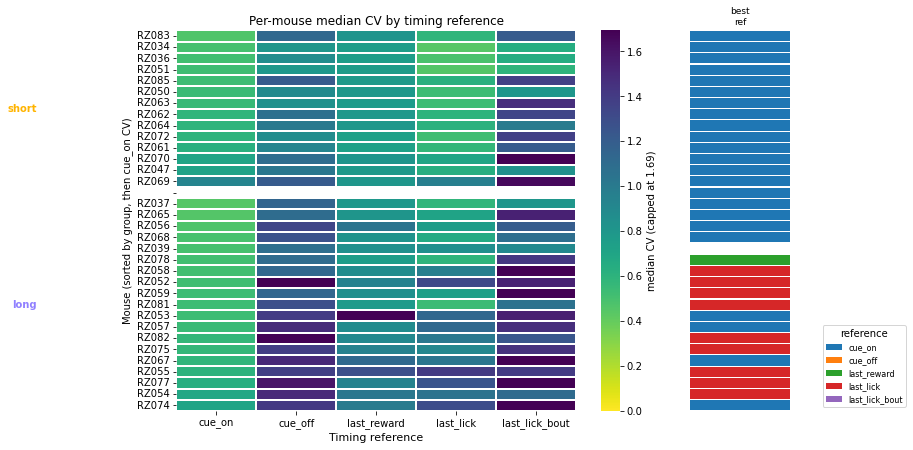

In [21]:
mouse_cv = (
    session_cvs
    .groupby(['mouse', 'group', 'reference'])['cv']
    .median()
    .reset_index()
    .rename(columns={'cv': 'median_cv'})
)

mouse_pivot = mouse_cv.pivot_table(index='mouse', columns='reference', values='median_cv')
mouse_pivot['best_ref'] = mouse_pivot[ref_order].idxmin(axis=1)

# Add group label for sorting
mouse_group = session_cvs[['mouse', 'group']].drop_duplicates().set_index('mouse')['group']
mouse_pivot['group'] = mouse_pivot.index.map(mouse_group)

# Sort: group first, then by cue_on CV within group
mouse_pivot = mouse_pivot.sort_values(['group', 'cue_on'])

print("Best reference per mouse:")
print(mouse_pivot[['group', 'best_ref']].to_string())

# Cap colorscale
vmax = mouse_pivot[ref_order].stack().quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(11, 7),
                         gridspec_kw={'width_ratios': [5, 1], 'wspace': 0.05})

# Left: heatmap
ax = axes[0]
# Add a gap between groups by inserting a NaN row
s_mice = mouse_pivot[mouse_pivot['group'] == 's'][ref_order]
l_mice = mouse_pivot[mouse_pivot['group'] == 'l'][ref_order]
gap = pd.DataFrame([[np.nan] * len(ref_order)], columns=ref_order, index=[''])
heat_data = pd.concat([s_mice, gap, l_mice])

sns.heatmap(
    heat_data, cmap='viridis_r', ax=ax,
    vmin=0, vmax=vmax,
    cbar_kws={'label': f'median CV (capped at {vmax:.2f})'},
    linewidths=0.3, linecolor='white'
)
ax.set_xlabel('Timing reference', fontsize=11)
ax.set_ylabel('Mouse (sorted by group, then cue_on CV)', fontsize=10)
ax.set_title('Per-mouse median CV by timing reference', fontsize=12)

# Add group labels on y-axis
n_s = len(s_mice)
n_l = len(l_mice)
ax.axhline(n_s, color='white', lw=3)
ax.text(-0.35, n_s / 2, 'short', va='center', ha='right',
        fontsize=10, color='#ffb400', fontweight='bold', transform=ax.get_yaxis_transform())
ax.text(-0.35, n_s + 1 + n_l / 2, 'long', va='center', ha='right',
        fontsize=10, color='#9080ff', fontweight='bold', transform=ax.get_yaxis_transform())

# Right: best_ref bar coloured by reference
ax2 = axes[1]
best_data = pd.concat([
    mouse_pivot[mouse_pivot['group'] == 's'][['best_ref']],
    pd.DataFrame([['gap']], columns=['best_ref'], index=['']),
    mouse_pivot[mouse_pivot['group'] == 'l'][['best_ref']]
])
ref_colors = dict(zip(ref_order, sns.color_palette('tab10', len(ref_order))))
bar_colors = [ref_colors.get(r, 'white') for r in best_data['best_ref']]
ax2.barh(range(len(best_data)), [1] * len(best_data), color=bar_colors, height=0.9)
ax2.set_xlim(0, 1)
ax2.set_ylim(-0.5, len(best_data) - 0.5)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title('best\nref', fontsize=9)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ref_colors[r], label=r) for r in ref_order]
ax2.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(2.2, 0), fontsize=8, title='reference')
sns.despine(ax=ax2, left=True, bottom=True)

plt.savefig(os.path.join(figure_folder, 'mouse_cv_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## CV vs. session number — does the timing anchor shift with training?

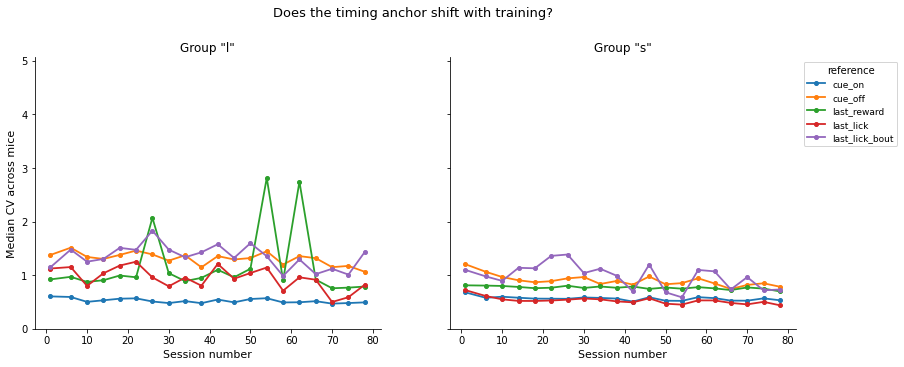

In [25]:
# Pull session number from trials (one value per dir)
session_num = (
    trials[['dir', 'session']].drop_duplicates()
    if 'session' in trials.columns
    else trials_training[['dir', 'session']].drop_duplicates()
)
cv_by_session = session_cvs.merge(session_num, on='dir', how='left')

# Bin session numbers so each bin has enough mice to be meaningful
N_SESSION_BINS = 20
cv_by_session['session_bin'] = pd.cut(
    cv_by_session['session'], bins=N_SESSION_BINS, labels=False
)
# Get bin midpoints for x-axis labelling
bin_edges = pd.cut(cv_by_session['session'], bins=N_SESSION_BINS, retbins=True)[1]
bin_mids = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype(int)

# Median CV per session bin × reference × group
binned = (
    cv_by_session
    .groupby(['session_bin', 'reference', 'group'])['cv']
    .median()
    .reset_index()
)

groups = sorted(binned['group'].dropna().unique())
group_palette = {'s': '#ffb400', 'l': '#9080ff'}
ref_colors = dict(zip(ref_order, sns.color_palette('tab10', len(ref_order))))
y_cap = cv_by_session['cv'].quantile(0.95)

fig, axes = plt.subplots(1, len(groups), figsize=(7 * len(groups), 5), sharey=True)

for ax, grp in zip(axes, groups):
    grp_data = binned[binned['group'] == grp]
    for ref in ref_order:
        sub = grp_data[grp_data['reference'] == ref].sort_values('session_bin')
        x = sub['session_bin'].map(lambda b: bin_mids[int(b)] if not pd.isna(b) else np.nan)
        ax.plot(x, sub['cv'], marker='o', markersize=4, lw=1.8,
                color=ref_colors[ref], label=ref)

    ax.set_ylim(0, y_cap)
    ax.set_xlabel('Session number', fontsize=11)
    ax.set_title(f'Group "{grp}"', fontsize=12)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    sns.despine(ax=ax)

axes[0].set_ylabel('Median CV across mice', fontsize=11)
axes[-1].legend(title='reference', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.suptitle('Does the timing anchor shift with training?', fontsize=13, y=1.02)
fig.subplots_adjust(right=0.88)
plt.savefig(os.path.join(figure_folder, 'cv_vs_session_number.png'), dpi=150, bbox_inches='tight')
plt.show()

In [26]:
for grp in groups:
    print(f"\n{'='*60}")
    print(f"Group '{grp}'")
    print(f"{'='*60}")

    grp_data = binned[binned['group'] == grp].copy()
    grp_data['session_mid'] = grp_data['session_bin'].map(
        lambda b: bin_mids[int(b)] if not pd.isna(b) else np.nan
    )

    # Pivot: rows = session bin, columns = reference
    table = grp_data.pivot_table(index='session_mid', columns='reference', values='cv')[ref_order]
    table.index.name = 'session'
    table['winner'] = table.idxmin(axis=1)

    print(table.round(3).to_string())

    # Also print how often each reference wins across session bins
    print(f"\n  Reference wins across session bins:")
    print(f"  {table['winner'].value_counts().to_string()}")


Group 'l'
reference  cue_on  cue_off  last_reward  last_lick  last_lick_bout  winner
session                                                                   
1           0.604    1.376        0.921      1.124           1.145  cue_on
6           0.593    1.512        0.969      1.151           1.477  cue_on
10          0.502    1.340        0.874      0.800           1.251  cue_on
14          0.531    1.303        0.906      1.035           1.302  cue_on
18          0.561    1.378        0.993      1.179           1.510  cue_on
22          0.568    1.458        0.961      1.251           1.473  cue_on
26          0.509    1.387        2.070      0.959           1.830  cue_on
30          0.480    1.270        1.038      0.793           1.476  cue_on
34          0.517    1.371        0.889      0.955           1.334  cue_on
38          0.478    1.147        0.950      0.804           1.426  cue_on
42          0.545    1.356        1.100      1.209           1.576  cue_on
46          0.

## `time_waited` vs `time_waited_since_last_lick`

Is the last lick happening near cue_off (suggesting the mouse uses its own lick to self-time the transition), or is it independent?

- `time_waited` = time from cue_off to decision lick
- `time_waited_since_last_lick` = time from last lick to decision lick
- difference = `time_waited` − `time_waited_since_last_lick` = time from cue_off to the last lick before the decision lick (negative if last lick was before cue_off, i.e. during background)

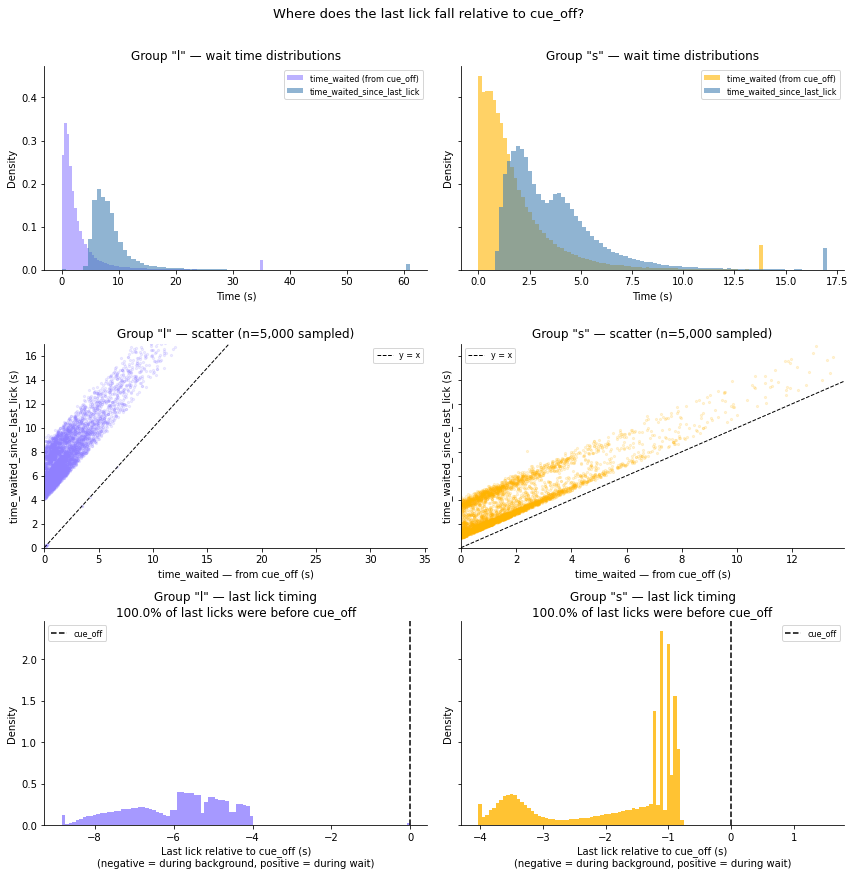

                                     short        long
  median time_waited (s)               1.266       1.705
  median time_since_last_lick (s)       3.152       7.875
  median last_lick_rel_cue_off (s)      -1.217      -5.726


In [27]:
groups = sorted(trials['group'].dropna().unique())
group_palette = {'s': '#ffb400', 'l': '#9080ff'}

# Difference: cue_off to last lick (negative = last lick was during background)
trials['last_lick_relative_to_cue_off'] = (
    trials['time_waited'] - trials['time_waited_since_last_lick']
)

fig, axes = plt.subplots(3, len(groups), figsize=(6 * len(groups), 12), sharey='row')

for col, grp in enumerate(groups):
    g = trials[trials['group'] == grp].dropna(
        subset=['time_waited', 'time_waited_since_last_lick']
    )
    color = group_palette[grp]
    x_cap_tw   = g['time_waited'].quantile(0.99)
    x_cap_ll   = g['time_waited_since_last_lick'].quantile(0.99)
    x_cap_diff = g['last_lick_relative_to_cue_off'].abs().quantile(0.99)

    # Row 0: overlaid distributions of time_waited vs time_waited_since_last_lick
    ax = axes[0, col]
    ax.hist(g['time_waited'].clip(upper=x_cap_tw),
            bins=80, alpha=0.6, color=color, label='time_waited (from cue_off)', density=True)
    ax.hist(g['time_waited_since_last_lick'].clip(upper=x_cap_ll),
            bins=80, alpha=0.6, color='steelblue', label='time_waited_since_last_lick', density=True)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Density')
    ax.set_title(f'Group "{grp}" — wait time distributions')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

    # Row 1: scatter time_waited vs time_waited_since_last_lick (sample for speed)
    ax = axes[1, col]
    sample = g.sample(min(5000, len(g)), random_state=0)
    ax.scatter(sample['time_waited'], sample['time_waited_since_last_lick'],
               alpha=0.15, s=5, color=color)
    lim = max(x_cap_tw, x_cap_ll)
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='y = x')  # equality line
    ax.set_xlim(0, x_cap_tw)
    ax.set_ylim(0, x_cap_ll)
    ax.set_xlabel('time_waited — from cue_off (s)')
    ax.set_ylabel('time_waited_since_last_lick (s)')
    ax.set_title(f'Group "{grp}" — scatter (n={len(sample):,} sampled)')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

    # Row 2: distribution of (time_waited − time_waited_since_last_lick)
    # = where the last lick fell relative to cue_off
    # negative → last lick was before cue_off (during background)
    # positive → last lick was after cue_off (during wait period)
    ax = axes[2, col]
    diff = g['last_lick_relative_to_cue_off'].clip(-x_cap_diff, x_cap_diff)
    ax.hist(diff, bins=100, color=color, alpha=0.8, density=True)
    ax.axvline(0, color='black', lw=1.5, linestyle='--', label='cue_off')
    pct_before = (g['last_lick_relative_to_cue_off'] < 0).mean() * 100
    ax.set_xlabel('Last lick relative to cue_off (s)\n(negative = during background, positive = during wait)')
    ax.set_ylabel('Density')
    ax.set_title(f'Group "{grp}" — last lick timing\n'
                 f'{pct_before:.1f}% of last licks were before cue_off')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('Where does the last lick fall relative to cue_off?', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'time_waited_vs_last_lick.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f"{'':30s}  {'short':>10}  {'long':>10}")
for label, col in [('median time_waited (s)',          'time_waited'),
                   ('median time_since_last_lick (s)', 'time_waited_since_last_lick'),
                   ('median last_lick_rel_cue_off (s)','last_lick_relative_to_cue_off')]:
    vs = trials[trials['group']=='s'][col].median()
    vl = trials[trials['group']=='l'][col].median()
    print(f"  {label:30s}  {vs:>10.3f}  {vl:>10.3f}")

## BG length distribution by group

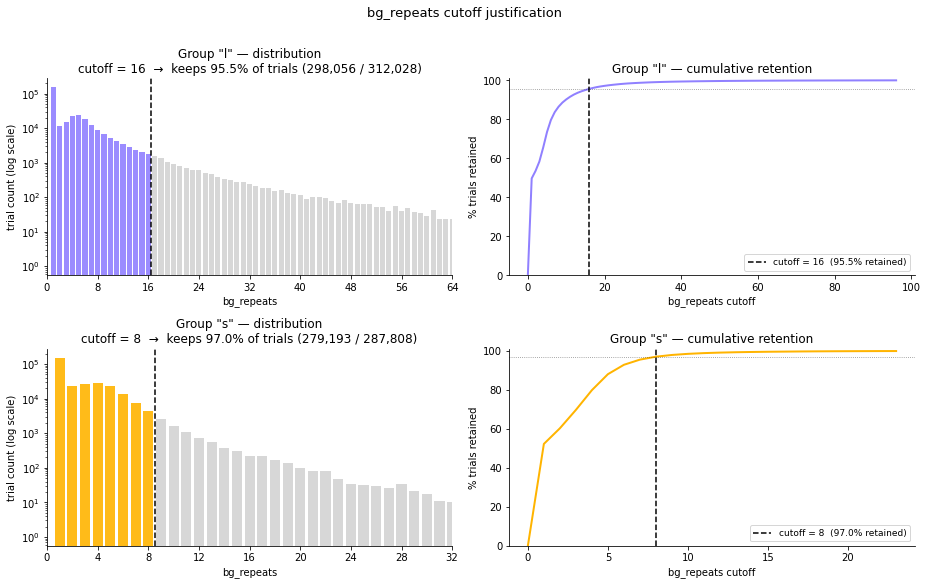

Cutoff summary:
  Group 'l': cutoff=16  kept=298,056  dropped=13,972 (4.5%)
  Group 's': cutoff=8  kept=279,193  dropped=8,615 (3.0%)


In [22]:
all_hit_trials = trials_training[~trials_training['miss_trial']].copy()
group_palette = {'s': '#ffb400', 'l': '#9080ff'}
groups = sorted(all_hit_trials['group'].dropna().unique())

BG_REPEAT_CUTOFF = {'s': 8, 'l': 16}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, grp in enumerate(groups):
    g = all_hit_trials[all_hit_trials['group'] == grp]['bg_repeats'].dropna()
    cutoff = BG_REPEAT_CUTOFF[grp]
    color = group_palette[grp]
    n_kept = (g <= cutoff).sum()
    n_total = len(g)
    pct_kept = n_kept / n_total * 100

    # Left: bar chart with cutoff line
    ax = axes[row, 0]
    counts = g.value_counts().sort_index()
    bar_colors = [color if i <= cutoff else 'lightgray' for i in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, width=0.8, alpha=0.9)
    ax.axvline(cutoff + 0.5, color='black', lw=1.5, linestyle='--')
    ax.set_yscale('log')
    ax.set_xlabel('bg_repeats')
    ax.set_ylabel('trial count (log scale)')
    ax.set_title(f'Group "{grp}" — distribution\n'
                 f'cutoff = {cutoff}  →  keeps {pct_kept:.1f}% of trials ({n_kept:,} / {n_total:,})')
    ax.set_xlim(0, min(counts.index.max(), cutoff * 4))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    sns.despine(ax=ax)

    # Right: cumulative % retained as cutoff moves
    ax = axes[row, 1]
    repeat_vals = np.arange(0, int(g.quantile(0.999)) + 1)
    cum_pct = [(g <= v).sum() / n_total * 100 for v in repeat_vals]
    ax.plot(repeat_vals, cum_pct, color=color, lw=2)
    ax.axvline(cutoff, color='black', lw=1.5, linestyle='--',
               label=f'cutoff = {cutoff}  ({pct_kept:.1f}% retained)')
    ax.axhline(pct_kept, color='black', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_xlabel('bg_repeats cutoff')
    ax.set_ylabel('% trials retained')
    ax.set_title(f'Group "{grp}" — cumulative retention')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 101)
    sns.despine(ax=ax)

fig.suptitle('bg_repeats cutoff justification', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(figure_folder, 'bg_repeats_cutoff_justification.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("Cutoff summary:")
for grp in groups:
    g = all_hit_trials[all_hit_trials['group'] == grp]['bg_repeats'].dropna()
    cutoff = BG_REPEAT_CUTOFF[grp]
    n_kept = (g <= cutoff).sum()
    n_dropped = len(g) - n_kept
    print(f"  Group '{grp}': cutoff={cutoff}  kept={n_kept:,}  "
          f"dropped={n_dropped:,} ({n_dropped/len(g)*100:.1f}%)")